#### Libraries

In [2]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.append(os.path.abspath(".."))

from libraries import torch, nn, optim, Accuracy, DataLoader, plt

#### Load variables

In [3]:
vars = torch.load('../saved_values/variables.pt', weights_only=False)
train_dataset = vars['train_dataset']
valid_loader = vars['valid_loader']

#### Utils

In [4]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#### Implementation of the MLP Model with Activation Functions: ReLU, LeakyReLU, and GELU

In [5]:
# Network architecture parameters
in_features = 12
out_features = 1
h1 = 64
h2 = 32
h3 = 16

#### 1. ReLU

![ReLU](../images/ReLU.jpg)

In [6]:
def mlp_model_relu():
    """Model with ReLU activation function"""
    model = nn.Sequential(nn.Linear(in_features, h1),
                            nn.ReLU(),
                            nn.Linear(h1, h2),
                            nn.ReLU(),
                            nn.Linear(h2, h3),
                            nn.ReLU(),
                            nn.Linear(h3, out_features),
                            nn.Sigmoid())
    return model

#### 2. Leaky ReLU

![LeakyReLU](../images/LeakyReLU.jpg)

In [7]:
def mlp_model_leaky_relu():
    """Model with LeakyReLU activation function"""
    model = nn.Sequential(nn.Linear(in_features, h1),
                            nn.LeakyReLU(),
                            nn.Linear(h1, h2),
                            nn.LeakyReLU(),
                            nn.Linear(h2, h3),
                            nn.LeakyReLU(),
                            nn.Linear(h3, out_features),
                            nn.Sigmoid())
    return model

#### 3. GELU

![GELI](../images/GELU.jpg)

In [8]:
def mlp_model_gelu():
    """Model with GeLU activation function"""
    model = nn.Sequential(nn.Linear(in_features, h1),
                            nn.GELU(),
                            nn.Linear(h1, h2),
                            nn.GELU(),
                            nn.Linear(h2, h3),
                            nn.GELU(),
                            nn.Linear(h3, out_features),
                            nn.Sigmoid())
    return model

#### Train model with activation functions: ReLU, LeakyReLU, and GeLU

In [9]:
from param import output


loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

af_index = {0: "ReLU", 1: "LeakyReLU", 2:"GeLU"}

for i, model in enumerate([mlp_model_relu(), mlp_model_leaky_relu(), mlp_model_gelu()]):
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    loss_fn = loss_fn = nn.BCELoss()
    num_epoch = 600

    for epoch in range(num_epoch):
        loss_train = AverageMeter()
        acc_train = Accuracy(task='binary')

        for inputs, targets in train_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), targets)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_train.update(loss.item())
            acc_train(outputs.squeeze(), targets)

        loss_train_hist.append(loss_train.avg)
        acc_train_hist.append(acc_train.compute().cpu())

        with torch.no_grad():
            loss_valid = AverageMeter()
            acc_valid = Accuracy(task='binary')
            for inputs, targets in valid_loader:
                outputs = model(inputs)

                loss_valid.update(loss.item())
                acc_valid(outputs.squeeze(), targets)

        loss_valid_hist.append(loss_valid.avg)
        acc_valid_hist.append(acc_valid.compute())

        if epoch % 10 == 0:
            print(f'Epoch: {epoch} | Activation Function: {af_index[i]}')
            print(f'\tTrain Loss: {loss_train.avg:.4f} | Train Accuracy: {acc_train.compute():.4f}')
            print(f'\tValidation Loss: {loss_valid.avg:.4f} | Validation Accuracy: {acc_valid.compute():.4f}\n')

Epoch: 0 | Activation Function: ReLU
	Train Loss: 0.6938 | Train Accuracy: 0.4472
	Validation Loss: 0.6906 | Validation Accuracy: 0.4774

Epoch: 10 | Activation Function: ReLU
	Train Loss: 0.6751 | Train Accuracy: 0.6884
	Validation Loss: 0.6473 | Validation Accuracy: 0.6884

Epoch: 20 | Activation Function: ReLU
	Train Loss: 0.6609 | Train Accuracy: 0.6834
	Validation Loss: 0.5971 | Validation Accuracy: 0.6834

Epoch: 30 | Activation Function: ReLU
	Train Loss: 0.6501 | Train Accuracy: 0.6834
	Validation Loss: 0.5742 | Validation Accuracy: 0.6834

Epoch: 40 | Activation Function: ReLU
	Train Loss: 0.6424 | Train Accuracy: 0.6834
	Validation Loss: 0.7611 | Validation Accuracy: 0.6834

Epoch: 50 | Activation Function: ReLU
	Train Loss: 0.6350 | Train Accuracy: 0.6834
	Validation Loss: 0.6348 | Validation Accuracy: 0.6834

Epoch: 60 | Activation Function: ReLU
	Train Loss: 0.6299 | Train Accuracy: 0.6834
	Validation Loss: 0.7650 | Validation Accuracy: 0.6834

Epoch: 70 | Activation Funct

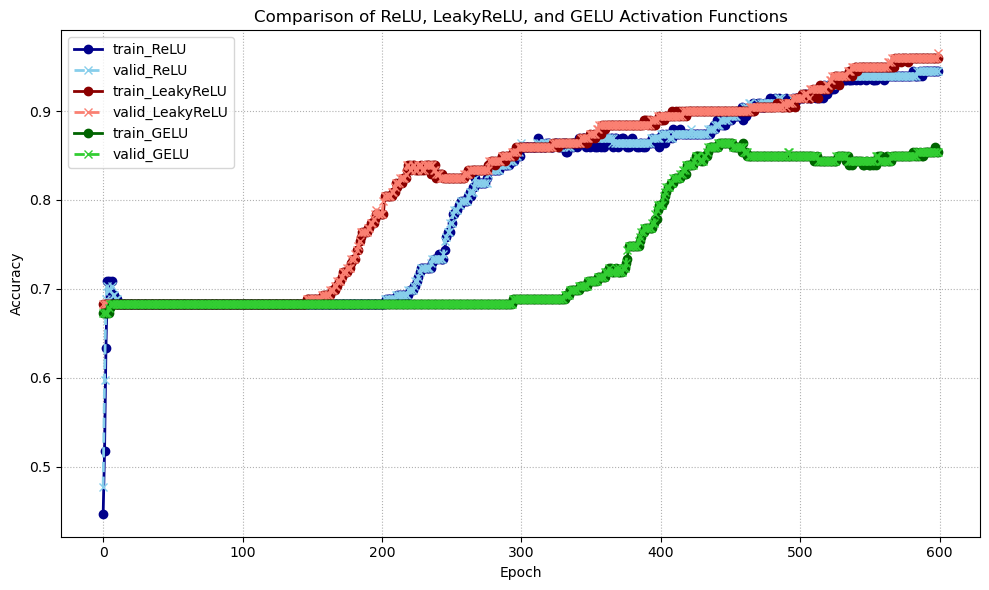

In [10]:
plt.figure(figsize=(10,6))

colors = ['darkblue', 'darkred', 'darkgreen']
light_colors = ['skyblue', 'salmon', 'limegreen']

activations = ['ReLU', 'LeakyReLU', 'GELU']

for i, af in enumerate(activations):

    start = i * num_epoch
    end = (i + 1) * num_epoch

    # Train Accuracy
    plt.plot(
        range(num_epoch),
        acc_train_hist[start:end],
        color=colors[i],
        linewidth=2,
        marker='o',
        label=f'train_{af}'
    )

    # Validation Accuracy
    plt.plot(
        range(num_epoch),
        acc_valid_hist[start:end],
        color=light_colors[i],
        linewidth=2,
        linestyle='--',
        marker='x',
        label=f'valid_{af}'
    )

plt.title("Comparison of ReLU, LeakyReLU, and GELU Activation Functions")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

plt.show()